In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
# 1) Path to your MEPS longitudinal .dat file (Panel 16: h156)
file_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h156dat\h156.dat"

# 2) Fixed-width column specs from the SAS layout (start,end) 0-based, end-exclusive
#    Each tuple = (start_position, end_position)
colspecs = [
    (0, 5),        # DUID       @1     5
    (5, 8),        # PID        @6     3
    (8, 16),       # DUPERSID   @9     8
    (16, 18),      # PANEL      @17    2
    (18, 19),      # YEARIND    @19    1

    (360, 362),    # AGE1X      @361   2
    (384, 385),    # SEX        @385   1
    (387, 389),    # RACEV1X    @388   2
    (398, 399),    # HISPANX    @399   1
    (128, 130),    # REGION1    @129   2

    (3145, 3147),  # POVCATY1   @3146  2
    (456, 458),    # EDRECODE   @457   2

    (4587, 4589),  # INSCOVY1   @4588  2

    (2342, 2344),  # HAVEUS2    @2343  2
    (2518, 2520),  # PHNREG2    @2519  2
    (2181, 2183),  # CMNAFF3    @2182  2

    (536, 538),    # RTHLTH1    @537   2
    (538, 540),    # RTHLTH2    @539   2
    (546, 548),    # MNHLTH1    @547   2
    (548, 550),    # MNHLTH2    @549   2

    (556, 558),    # HIBPDXY1   @557   2
    (558, 560),    # HIBPDXY2   @559   2
    (898, 900),    # DIABDXY1   @899   2
    (900, 902),    # DIABDXY2   @901   2

    (5568, 5571),  # OBTOTVY2   @5569  3
]

# 3) Names in the same order as colspecs
names = [
    "DUID", "PID", "DUPERSID", "PANEL", "YEARIND",
    "AGE1X", "SEX", "RACEV1X", "HISPANX", "REGION1",
    "POVCATY1", "EDRECODE",
    "INSCOVY1",
    "HAVEUS2", "PHNREG2", "CMNAFF3",
    "RTHLTH1", "RTHLTH2", "MNHLTH1", "MNHLTH2",
    "HIBPDXY1", "HIBPDXY2", "DIABDXY1", "DIABDXY2",
    "OBTOTVY2",
]

# 4) Read only these columns from the fixed-width file
df = pd.read_fwf(
    file_path,
    colspecs=colspecs,
    names=names,
    dtype=str  # read as strings first, convert later
)

print("Raw shape:", df.shape)
print(df.head())

Raw shape: (18512, 25)
    DUID  PID  DUPERSID PANEL YEARIND AGE1X SEX RACEV1X HISPANX REGION1  ...  \
0  30001  101  30001101    16       1    54   2      01       1      03  ...   
1  30002  101  30002101    16       1    61   1      01       2      02  ...   
2  30002  102  30002102    16       1    60   2      01       2      02  ...   
3  30003  101  30003101    16       1    85   2      01       1      04  ...   
4  30003  102  30003102    16       1    60   2      01       1      04  ...   

  CMNAFF3 RTHLTH1 RTHLTH2 MNHLTH1 MNHLTH2 HIBPDXY1 HIBPDXY2 DIABDXY1 DIABDXY2  \
0      -1      04      05      04      05       01       01       01       01   
1      -1      02      04      01      01       02       02       02       02   
2      -1      01      01      01      01       02       02       02       02   
3      -1      01      01      01      01       02       02       02       02   
4      -1      03      01      03      01       02       02       02       02   

  OBTOTVY

In [4]:
# Convert selected columns to numeric (keep DUPERSID as string)
numeric_cols = [c for c in df.columns if c not in ["DUPERSID"]]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Filter to adults (Year-1 age ≥ 18)
df_adults = df[df["AGE1X"] >= 18].copy()

print("Adult sample shape:", df_adults.shape)
df_adults.head()


Adult sample shape: (12925, 25)


,DUID,PID,DUPERSID,PANEL,YEARIND,AGE1X,SEX,RACEV1X,HISPANX,REGION1,...,CMNAFF3,RTHLTH1,RTHLTH2,MNHLTH1,MNHLTH2,HIBPDXY1,HIBPDXY2,DIABDXY1,DIABDXY2,OBTOTVY2
0,30001,101,30001101,16,1,54,2,1,1,3,...,-1,4,5,4,5,1,1,1,1,9
1,30002,101,30002101,16,1,61,1,1,2,2,...,-1,2,4,1,1,2,2,2,2,8
2,30002,102,30002102,16,1,60,2,1,2,2,...,-1,1,1,1,1,2,2,2,2,5
3,30003,101,30003101,16,1,85,2,1,1,4,...,-1,1,1,1,1,2,2,2,2,0
4,30003,102,30003102,16,1,60,2,1,1,4,...,-1,3,1,3,1,2,2,2,2,0


In [5]:
df.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'HAVEUS2', 'PHNREG2', 'CMNAFF3', 'RTHLTH1', 'RTHLTH2', 'MNHLTH1',
       'MNHLTH2', 'HIBPDXY1', 'HIBPDXY2', 'DIABDXY1', 'DIABDXY2', 'OBTOTVY2'],
      dtype='object')

In [6]:
cols_to_remove = [
    "HAVEUS2",
    "PHNREG2",
    "RTHLTH2",
    "MNHLTH2",
    "HIBPDXY2",
    "DIABDXY2"
]

In [7]:
df_model = df.drop(columns=cols_to_remove)

In [8]:
df_model.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'CMNAFF3', 'RTHLTH1', 'MNHLTH1', 'HIBPDXY1', 'DIABDXY1', 'OBTOTVY2'],
      dtype='object')

In [9]:
df["OBTOTVY2"].describe()

count    18512.000000
mean         3.819901
std          8.331276
min         -1.000000
25%          0.000000
50%          1.000000
75%          4.000000
max        192.000000
Name: OBTOTVY2, dtype: float64

In [10]:
(df["OBTOTVY2"] == 0).mean()

0.34772039757994816

In [11]:
df["OBTOTVY2"].value_counts().head(10)

OBTOTVY2
0    6437
1    3282
2    2066
3    1361
4     928
5     695
6     566
7     434
8     334
9     285
Name: count, dtype: int64

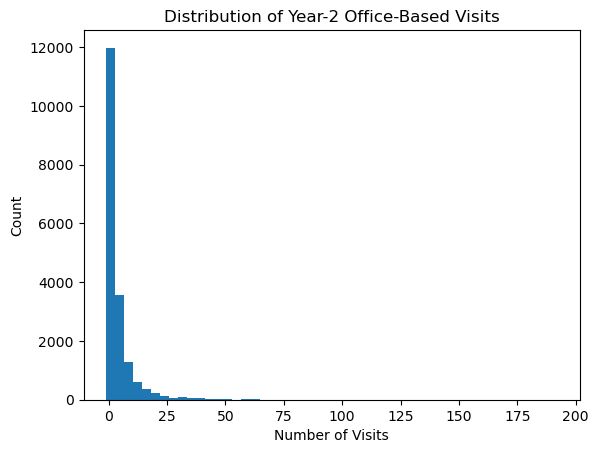

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["OBTOTVY2"], bins=50)
plt.title("Distribution of Year-2 Office-Based Visits")
plt.xlabel("Number of Visits")
plt.ylabel("Count")
plt.show()

##### Year-2 office-based provider visits exhibit a zero-inflated and highly skewed distribution, motivating a two-stage modeling framework that first predicts the likelihood of any utilization, followed by modeling the intensity of visits among utilizers.

In [14]:
df["OBTOTVY2"] = df["OBTOTVY2"].replace(-1, np.nan)

In [15]:
df["OBTOTVY2"] = df["OBTOTVY2"].replace(-1, np.nan)

In [16]:
df_utilizers = df[df["OBTOTVY2"] > 0].copy()

In [17]:
df["any_visit_y2"] = (df["OBTOTVY2"] > 0).astype(int)

In [18]:
df["any_visit_y2"].value_counts(dropna=False)

any_visit_y2
1    11876
0     6636
Name: count, dtype: int64

In [19]:
df.groupby("CMNAFF3")["any_visit_y2"].mean()
df.groupby("INSCOVY1")["any_visit_y2"].mean()
df.groupby("HAVEUS2")["any_visit_y2"].mean()

HAVEUS2
-9    0.333333
-8    0.354839
-7    0.465753
-1    0.599553
 1    0.728672
 2    0.387364
Name: any_visit_y2, dtype: float64

In [20]:
df = df[df["OBTOTVY2"] >= 0]

In [21]:
df.loc[:, "any_visit_y2"] = (df["OBTOTVY2"] > 0).astype(int)

In [22]:
df = df[df["OBTOTVY2"] >= 0].copy()
df["any_visit_y2"] = (df["OBTOTVY2"] > 0).astype(int)


In [23]:
df["any_visit_y2"].value_counts(normalize=True)


any_visit_y2
1    0.648501
0    0.351499
Name: proportion, dtype: float64

A majority of adults have at least one office-based provider visit in Year 2.
The outcome is not extremely rare, but it is still imbalanced.
This is perfectly suitable for:

Logistic regression & Two-stage modeling

No need for SMOTE.

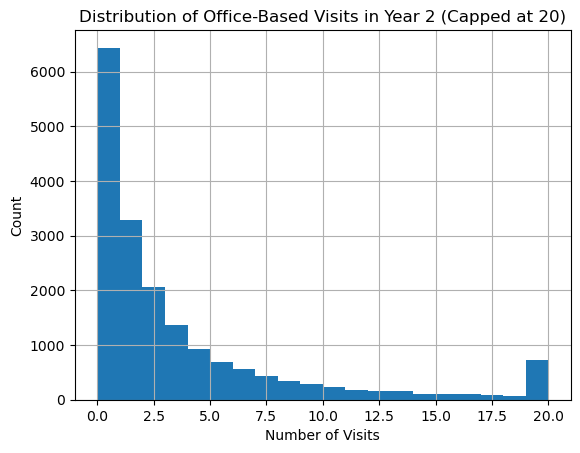

In [25]:
df["OBTOTVY2"].clip(upper=20).hist(bins=20)
plt.title("Distribution of Office-Based Visits in Year 2 (Capped at 20)")
plt.xlabel("Number of Visits")
plt.ylabel("Count")
plt.show()


In [26]:
df.groupby("HAVEUS2")["any_visit_y2"].mean()


HAVEUS2
-9    0.500000
-8    0.362140
-7    0.465753
-1    0.812121
 1    0.731269
 2    0.389948
Name: any_visit_y2, dtype: float64

# Loading the other datasets

In [28]:
import pandas as pd

# Fixed-width column specs for the variables we chose (same across longitudinal panels)
COLSPECS = {
    "DUID":      (0, 5),       # @1   5 chars
    "PID":       (5, 8),       # @6   3 chars
    "DUPERSID":  (8, 16),      # @9   8 chars
    "PANEL":     (16, 18),     # @17  2 chars
    "YEARIND":   (18, 19),     # @19  1 char

    "REGION1":   (128, 130),   # @129 2 chars

    "AGE1X":     (360, 362),   # @361 2 chars
    "SEX":       (384, 385),   # @385 1 char
    "RACEV1X":   (387, 389),   # @388 2 chars
    "HISPANX":   (398, 399),   # @399 1 char

    "EDRECODE":  (456, 458),   # @457 2 chars

    "RTHLTH1":   (536, 538),   # @537 2 chars
    "MNHLTH1":   (546, 548),   # @547 2 chars
    "HIBPDXY1":  (556, 558),   # @557 2 chars
    "DIABDXY1":  (898, 900),   # @899 2 chars

    "CMNAFF3":   (2181, 2183), # @2182 2 chars
    "HAVEUS2":   (2342, 2344), # @2343 2 chars
    "PHNREG2":   (2518, 2520), # @2519 2 chars

    "POVCATY1":  (3145, 3147), # @3146 2 chars

    "INSCOVY1":  (4587, 4589), # @4588 2 chars

    "OBTOTVY2":  (5568, 5571), # @5569 3 chars (Year-2 total office-based visits)
}

def load_meps_panel(filepath, panel_id):
    """
    Load a MEPS longitudinal .dat file for one panel,
    keeping only the selected columns and tagging with panel_id.
    """
    colspecs_list = list(COLSPECS.values())
    colnames = list(COLSPECS.keys())

    df = pd.read_fwf(
        filepath,
        colspecs=colspecs_list,
        names=colnames,
        dtype=str  # read as string first; we’ll convert later
    )

    # Add a numeric panel_id column (for later pooled analysis)
    df["panel_id"] = panel_id

    return df


In [29]:
p17_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h164dat\h164.dat"

df_p17 = load_meps_panel(p17_path, panel_id=17)

df_p17.head()
df_p17.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17923 entries, 0 to 17922
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DUID      17923 non-null  object
 1   PID       17923 non-null  object
 2   DUPERSID  17923 non-null  object
 3   PANEL     17923 non-null  object
 4   YEARIND   17923 non-null  object
 5   REGION1   17923 non-null  object
 6   AGE1X     17923 non-null  object
 7   SEX       17923 non-null  object
 8   RACEV1X   17923 non-null  object
 9   HISPANX   17923 non-null  object
 10  EDRECODE  17923 non-null  object
 11  RTHLTH1   17923 non-null  object
 12  MNHLTH1   17923 non-null  object
 13  HIBPDXY1  17923 non-null  object
 14  DIABDXY1  17923 non-null  object
 15  CMNAFF3   17923 non-null  object
 16  HAVEUS2   17923 non-null  object
 17  PHNREG2   17923 non-null  object
 18  POVCATY1  17923 non-null  object
 19  INSCOVY1  17923 non-null  object
 20  OBTOTVY2  17923 non-null  object
 21  panel_id  17

#### Using Medical Condition Files for panel 16

In [31]:
cond11_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h146dat\h146.dat"
cond12_path = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h154dat\h154.dat"

# colspecs are 0-based [start, end), derived from the SAS positions
colspecs = [
    (0, 5),   # DUID     @1
    (5, 8),   # PID      @6
    (8, 16),  # DUPERSID @9
    (31, 33), # PANEL    @32
    (64, 67), # ICD9CODX @65
    (69, 72), # CCCODEX  @70
]

names = ["DUID", "PID", "DUPERSID", "PANEL", "ICD9CODX", "CCCODEX"]

cond11 = pd.read_fwf(cond11_path, colspecs=colspecs, names=names, dtype=str)
cond12 = pd.read_fwf(cond12_path, colspecs=colspecs, names=names, dtype=str)

conditions_all = pd.concat([cond11, cond12], ignore_index=True)

# Clean PANEL as string
conditions_all["PANEL"] = conditions_all["PANEL"].str.strip()

In [32]:
# Filter to Panel 16
cond_p16 = conditions_all[conditions_all["PANEL"] == "16"].copy()

def is_cancer_icd(code):
    if code is None or pd.isna(code):
        return False
    code = code.strip()
    if not code.isdigit():
        return False
    val = int(code)
    # Neoplasms range in ICD-9
    return 140 <= val <= 239

def is_cancer_ccc(code):
    if code is None or pd.isna(code):
        return False
    code = code.strip()
    if not code.isdigit():
        return False
    val = int(code)
    # Broad cancer-related CC range (conservative)
    return 11 <= val <= 45

cond_p16["has_cancer_cond"] = cond_p16.apply(
    lambda row: is_cancer_icd(row["ICD9CODX"]) or is_cancer_ccc(row["CCCODEX"]),
    axis=1
)


In [33]:
cancer_flag_p16 = (
    cond_p16
    .groupby("DUPERSID")["has_cancer_cond"]
    .max()               # any True → 1
    .astype(int)
    .rename("has_cancer")
    .reset_index()
)

cancer_flag_p16["has_cancer"].value_counts()


has_cancer
0    15735
1     1396
Name: count, dtype: int64

In [34]:
df.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'HAVEUS2', 'PHNREG2', 'CMNAFF3', 'RTHLTH1', 'RTHLTH2', 'MNHLTH1',
       'MNHLTH2', 'HIBPDXY1', 'HIBPDXY2', 'DIABDXY1', 'DIABDXY2', 'OBTOTVY2',
       'any_visit_y2'],
      dtype='object')

In [35]:
# Ensure DUPERSID is clean string
df["DUPERSID"] = df["DUPERSID"].astype(str).str.strip()

df_merged = df.merge(cancer_flag_p16, on="DUPERSID", how="left")

# Missing => no cancer condition found
df_merged["has_cancer"] = df_merged["has_cancer"].fillna(0).astype(int)

# Convert age and filter adults
df_merged["AGE1X_num"] = pd.to_numeric(df_merged["AGE1X"], errors="coerce")

df_final_p16 = df_merged[
    (df_merged["AGE1X_num"] >= 18) &
    (df_merged["has_cancer"] == 0)
].copy()

print("Original rows:", len(df))
print("After adult + non-cancer filter:", len(df_final_p16))
df_final_p16[["has_cancer"]].value_counts()


Original rows: 18313
After adult + non-cancer filter: 11489


has_cancer
0             11489
Name: count, dtype: int64

In [36]:
df_final_p16

,DUID,PID,DUPERSID,PANEL,YEARIND,AGE1X,SEX,RACEV1X,HISPANX,REGION1,...,MNHLTH1,MNHLTH2,HIBPDXY1,HIBPDXY2,DIABDXY1,DIABDXY2,OBTOTVY2,any_visit_y2,has_cancer,AGE1X_num
0,30001,101,30001101,16,1,54,2,1,1,3,...,4,5,1,1,1,1,9.0,1,0,54
2,30002,102,30002102,16,1,60,2,1,2,2,...,1,1,2,2,2,2,5.0,1,0,60
3,30003,101,30003101,16,1,85,2,1,1,4,...,1,1,2,2,2,2,0.0,0,0,85
4,30003,102,30003102,16,1,60,2,1,1,4,...,3,1,2,2,2,2,0.0,0,0,60
5,30003,103,30003103,16,1,39,1,1,1,4,...,1,1,2,2,2,2,0.0,0,0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18306,39741,102,39741102,16,1,62,1,4,2,3,...,3,2,2,2,2,2,5.0,1,0,62
18307,39741,103,39741103,16,1,54,2,4,2,3,...,2,2,2,2,2,2,1.0,1,0,54
18308,39742,101,39742101,16,1,21,1,1,1,2,...,1,1,2,2,2,2,0.0,0,0,21
18309,39742,102,39742102,16,1,21,2,1,1,2,...,1,1,2,2,2,2,1.0,1,0,21


In [37]:
import numpy as np
import pandas as pd

# Clean up the condition codes
conditions_all["ICD9CODX"] = conditions_all["ICD9CODX"].astype(str).str.strip()
conditions_all["CCCODEX"]  = conditions_all["CCCODEX"].astype(str).str.strip()

# ICD-9 codes 140–239 → malignant neoplasms
icd_numeric = pd.to_numeric(
    conditions_all["ICD9CODX"].where(conditions_all["ICD9CODX"].str.len() > 0),
    errors="coerce"
)
cancer_icd = (icd_numeric >= 140) & (icd_numeric <= 239)

# CCS cancer buckets (rough): 11–45
ccc_numeric = pd.to_numeric(
    conditions_all["CCCODEX"].where(conditions_all["CCCODEX"].str.len() > 0),
    errors="coerce"
)
cancer_ccc = (ccc_numeric >= 11) & (ccc_numeric <= 45)

conditions_all["has_cancer_cond"] = np.where(cancer_icd | cancer_ccc, 1, 0)

print("Rows flagged as cancer in conditions_all:",
      conditions_all["has_cancer_cond"].sum())


Rows flagged as cancer in conditions_all: 4524


In [38]:
# Make sure PANEL and DUPERSID line up between frames
# (often they’re strings, but this is safe)
conditions_all["PANEL"] = conditions_all["PANEL"].astype(str)
df_final_p16["PANEL"]   = df_final_p16["PANEL"].astype(str)
df_final_p16["DUPERSID"] = df_final_p16["DUPERSID"].astype(str)

# Take only Panel 16 rows from condition file
cond_p16 = conditions_all[conditions_all["PANEL"] == "16"].copy()

# Collapse to person-level: if any condition is cancer, mark as 1
cancer_flag_p16 = (
    cond_p16.groupby("DUPERSID")["has_cancer_cond"]
    .max()
    .rename("has_cancer")
    .reset_index()
)

print(cancer_flag_p16.head())
print("Unique persons with cancer in Panel 16:",
      (cancer_flag_p16["has_cancer"] == 1).sum())


   DUPERSID  has_cancer
0  30001101           0
1  30002101           1
2  30002102           0
3  30003105           0
4  30003106           0
Unique persons with cancer in Panel 16: 1396


In [182]:
# Merge cancer flag into df_final_p16
df_final_p16 = df_final_p16.merge(cancer_flag_p16, on="DUPERSID", how="left")

# People with no condition rows → NaN → treat as no cancer
df_final_p16["has_cancer"] = df_final_p16["has_cancer"].fillna(0).astype(int)

print(df_final_p16[["DUPERSID", "has_cancer"]].head())
print(df_final_p16["has_cancer"].value_counts())


   DUPERSID  has_cancer
0  30001101           0
1  30002102           0
2  30003101           0
3  30003102           0
4  30003103           0
has_cancer
0    11489
Name: count, dtype: int64


In [184]:
# Make sure AGE1X is numeric
df_final_p16["AGE1X"] = pd.to_numeric(df_final_p16["AGE1X"], errors="coerce")

df_p16_adult_nonca = df_final_p16[
    (df_final_p16["AGE1X"] >= 18) &
    (df_final_p16["has_cancer"] == 0)
].copy()

print("Original rows (Panel 16):", len(df_final_p16))
print("Adult, non-cancer rows (Panel 16):", len(df_p16_adult_nonca))
print(df_p16_adult_nonca["has_cancer"].value_counts())


Original rows (Panel 16): 11489
Adult, non-cancer rows (Panel 16): 11489
has_cancer
0    11489
Name: count, dtype: int64


# now for panel 17

In [187]:
df_p17

,DUID,PID,DUPERSID,PANEL,YEARIND,REGION1,AGE1X,SEX,RACEV1X,HISPANX,...,MNHLTH1,HIBPDXY1,DIABDXY1,CMNAFF3,HAVEUS2,PHNREG2,POVCATY1,INSCOVY1,OBTOTVY2,panel_id
0,20004,101,20004101,17,1,03,39,0,10,2,...,10,20,1-,22,16,01,20,20,000,17
1,20004,102,20004102,17,1,03,40,0,10,1,...,10,20,1-,10,05,02,20,20,000,17
2,20004,103,20004103,17,1,03,10,0,60,7,...,1-,1-,1-,01,01,-1,20,20,000,17
3,20005,101,20005101,17,1,01,52,0,40,5,...,20,20,3-,13,08,-1,10,20,000,17
4,20005,102,20005102,17,1,01,22,0,50,5,...,10,20,1-,01,01,-1,10,20,000,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17918,29673,103,29673103,17,1,03,12,0,60,7,...,1-,1-,1-,01,01,-1,10,20,000,17
17919,29674,101,29674101,17,1,03,37,0,30,5,...,10,20,1-,08,05,02,20,20,000,17
17920,29674,102,29674102,17,1,03,31,0,30,5,...,10,20,1-,08,10,02,20,20,000,17
17921,29676,102,29676102,17,1,03,56,0,30,5,...,10,20,1-,08,10,02,20,20,000,17


In [188]:
df_p17_adult = df_p17.copy()
df_p17_adult["AGE1X"] = pd.to_numeric(df_p17_adult["AGE1X"], errors="coerce")

df_p17_adult = df_p17_adult[df_p17_adult["AGE1X"] >= 18]

print("After adult filter:", df_p17_adult.shape)


After adult filter: (12778, 22)


In [189]:
colspecs = [
    (8, 16),    # DUPERSID
    (69, 72)    # CCCODEX
]

cond_2012 = pd.read_fwf(
    r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h154dat\h154.dat",
    colspecs=colspecs,
    names=["DUPERSID", "CCCODEX"],
    dtype=str
)

cond_2013 = pd.read_fwf(
    r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h162dat\h162.dat",
    colspecs=colspecs,
    names=["DUPERSID", "CCCODEX"],
    dtype=str
)


In [190]:
conditions_p17 = pd.concat([cond_2012, cond_2013], ignore_index=True)

conditions_p17["is_cancer"] = conditions_p17["CCCODEX"].str.startswith("11")

cancer_flag = (
    conditions_p17
    .groupby("DUPERSID")["is_cancer"]
    .any()
    .reset_index()
    .rename(columns={"is_cancer": "has_cancer"})
)

print(cancer_flag["has_cancer"].value_counts())


has_cancer
False    41569
True      3955
Name: count, dtype: int64


In [191]:
df_p17_adult = df_p17_adult.merge(
    cancer_flag,
    on="DUPERSID",
    how="left"
)

df_p17_adult["has_cancer"] = df_p17_adult["has_cancer"].fillna(False)


C:\Users\abhin\AppData\Local\Temp\ipykernel_41212\644378253.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_p17_adult["has_cancer"] = df_p17_adult["has_cancer"].fillna(False)


In [192]:
df_p17_adult_nonca = df_p17_adult[df_p17_adult["has_cancer"] == 0].copy()

print("Final analytic sample:", df_p17_adult_nonca.shape)
print(df_p17_adult_nonca["has_cancer"].value_counts())



Final analytic sample: (11181, 23)
has_cancer
False    11181
Name: count, dtype: int64


In [193]:
df_p17_adult_nonca["OBTOTVY2"] = pd.to_numeric(df_p17_adult_nonca["OBTOTVY2"], errors="coerce")

df_p17_adult_nonca["any_visit_y2"] = (df_p17_adult_nonca["OBTOTVY2"] > 0).astype(int)

df_p17_adult_nonca["any_visit_y2"].value_counts(normalize=True)


any_visit_y2
0    0.980592
1    0.019408
Name: proportion, dtype: float64

In [194]:
df_p17_adult_nonca.columns.equals(df_p16_adult_nonca.columns)


False

In [195]:
df_p16_adult_nonca.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'HAVEUS2', 'PHNREG2', 'CMNAFF3', 'RTHLTH1', 'RTHLTH2', 'MNHLTH1',
       'MNHLTH2', 'HIBPDXY1', 'HIBPDXY2', 'DIABDXY1', 'DIABDXY2', 'OBTOTVY2',
       'any_visit_y2', 'has_cancer_x', 'AGE1X_num', 'has_cancer_y',
       'has_cancer'],
      dtype='object')

In [196]:
df_p17_adult_nonca.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'REGION1', 'AGE1X',
       'SEX', 'RACEV1X', 'HISPANX', 'EDRECODE', 'RTHLTH1', 'MNHLTH1',
       'HIBPDXY1', 'DIABDXY1', 'CMNAFF3', 'HAVEUS2', 'PHNREG2', 'POVCATY1',
       'INSCOVY1', 'OBTOTVY2', 'panel_id', 'has_cancer', 'any_visit_y2'],
      dtype='object')

## Combining panels 16 and 17

In [198]:
analytic_cols = [
    "DUID",
    "PID",
    "DUPERSID",
    "PANEL",
    "YEARIND",
    "REGION1",
    "AGE1X",
    "SEX",
    "RACEV1X",
    "HISPANX",
    "POVCATY1",
    "EDRECODE",
    "INSCOVY1",
    "HAVEUS2",
    "PHNREG2",
    "CMNAFF3",
    "RTHLTH1",
    "MNHLTH1",
    "HIBPDXY1",
    "DIABDXY1",
    "OBTOTVY2",     # response (Year 2 total office-based visits)
    "any_visit_y2", # binary response
]

In [199]:
df_p16_adult_nonca = df_p16_adult_nonca[analytic_cols].copy()
df_p17_adult_nonca = df_p17_adult_nonca[analytic_cols].copy()

In [200]:
df_p16_adult_nonca

,DUID,PID,DUPERSID,PANEL,YEARIND,REGION1,AGE1X,SEX,RACEV1X,HISPANX,...,INSCOVY1,HAVEUS2,PHNREG2,CMNAFF3,RTHLTH1,MNHLTH1,HIBPDXY1,DIABDXY1,OBTOTVY2,any_visit_y2
0,30001,101,30001101,16,1,3,54,2,1,1,...,2,1,3,-1,4,4,1,1,9.0,1
1,30002,102,30002102,16,1,2,60,2,1,2,...,1,1,4,-1,1,1,2,2,5.0,1
2,30003,101,30003101,16,1,4,85,2,1,1,...,3,2,-1,-1,1,1,2,2,0.0,0
3,30003,102,30003102,16,1,4,60,2,1,1,...,3,2,-1,-1,3,3,2,2,0.0,0
4,30003,103,30003103,16,1,4,39,1,1,1,...,3,2,-1,-1,1,1,2,2,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11484,39741,102,39741102,16,1,3,62,1,4,2,...,1,2,-1,-1,3,3,2,2,5.0,1
11485,39741,103,39741103,16,1,3,54,2,4,2,...,3,2,-1,-1,2,2,2,2,1.0,1
11486,39742,101,39742101,16,1,2,21,1,1,1,...,3,2,-1,-1,1,1,2,2,0.0,0
11487,39742,102,39742102,16,1,2,21,2,1,1,...,3,1,3,-1,1,1,2,2,1.0,1


In [201]:
df_p17_adult_nonca

,DUID,PID,DUPERSID,PANEL,YEARIND,REGION1,AGE1X,SEX,RACEV1X,HISPANX,...,INSCOVY1,HAVEUS2,PHNREG2,CMNAFF3,RTHLTH1,MNHLTH1,HIBPDXY1,DIABDXY1,OBTOTVY2,any_visit_y2
0,20004,101,20004101,17,1,03,39,0,10,2,...,20,16,01,22,20,10,20,1-,0.0,0
1,20004,102,20004102,17,1,03,40,0,10,1,...,20,05,02,10,20,10,20,1-,0.0,0
2,20005,101,20005101,17,1,01,52,0,40,5,...,20,08,-1,13,10,20,20,3-,0.0,0
3,20005,102,20005102,17,1,01,22,0,50,5,...,20,01,-1,01,20,10,20,1-,0.0,0
4,20005,103,20005103,17,1,01,19,0,50,5,...,20,01,-1,01,20,10,20,1-,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12773,29673,101,29673101,17,1,03,34,0,50,5,...,20,35,02,07,10,20,20,1-,0.0,0
12774,29674,101,29674101,17,1,03,37,0,30,5,...,20,05,02,08,20,10,20,1-,0.0,0
12775,29674,102,29674102,17,1,03,31,0,30,5,...,20,10,02,08,20,10,20,1-,0.0,0
12776,29676,102,29676102,17,1,03,56,0,30,5,...,20,10,02,08,20,10,20,1-,0.0,0


In [202]:
df_all_panels = pd.concat(
    [df_p16_adult_nonca, df_p17_adult_nonca],
    ignore_index=True
)

In [203]:
df_all_panels.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'REGION1', 'AGE1X',
       'SEX', 'RACEV1X', 'HISPANX', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'HAVEUS2', 'PHNREG2', 'CMNAFF3', 'RTHLTH1', 'MNHLTH1', 'HIBPDXY1',
       'DIABDXY1', 'OBTOTVY2', 'any_visit_y2'],
      dtype='object')

## eda with panels 16 and 17

In [205]:
df_all_panels.shape


(22670, 22)

In [206]:
df_all_panels.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22670 entries, 0 to 22669
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DUID          22670 non-null  object 
 1   PID           22670 non-null  object 
 2   DUPERSID      22670 non-null  object 
 3   PANEL         22670 non-null  object 
 4   YEARIND       22670 non-null  object 
 5   REGION1       22670 non-null  object 
 6   AGE1X         22670 non-null  int64  
 7   SEX           22670 non-null  object 
 8   RACEV1X       22670 non-null  object 
 9   HISPANX       22670 non-null  object 
 10  POVCATY1      22670 non-null  object 
 11  EDRECODE      22670 non-null  object 
 12  INSCOVY1      22670 non-null  object 
 13  HAVEUS2       22670 non-null  object 
 14  PHNREG2       22670 non-null  object 
 15  CMNAFF3       22670 non-null  object 
 16  RTHLTH1       22670 non-null  object 
 17  MNHLTH1       22670 non-null  object 
 18  HIBPDXY1      22670 non-nu

In [207]:
df_all_panels["OBTOTVY2"].describe()


count    22645.000000
mean         6.433871
std         53.174912
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        990.000000
Name: OBTOTVY2, dtype: float64

In [208]:
df_all_panels["any_visit_y2"].value_counts(normalize=True)


any_visit_y2
0    0.676268
1    0.323732
Name: proportion, dtype: float64

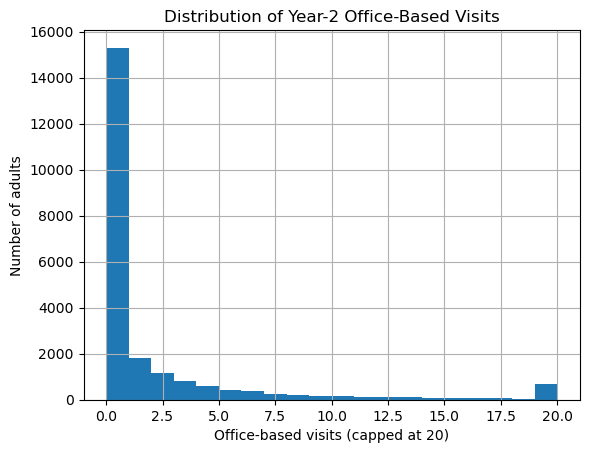

In [209]:
df_all_panels["OBTOTVY2"].clip(upper=20).hist(bins=20)
plt.xlabel("Office-based visits (capped at 20)")
plt.ylabel("Number of adults")
plt.title("Distribution of Year-2 Office-Based Visits")
plt.show()


In [210]:
df_all_panels.groupby("HAVEUS2")["any_visit_y2"].mean()


HAVEUS2
-9    0.000000
-8    0.303371
-7    0.403509
-1    0.600000
1     0.744385
        ...   
90    0.055556
94    0.000000
95    0.000000
98    0.000000
99    0.000000
Name: any_visit_y2, Length: 76, dtype: float64

In [211]:
df_all_panels.groupby("CMNAFF3")["any_visit_y2"].mean()


CMNAFF3
-9    0.933333
-1    0.619164
1     0.714286
2     1.000000
00    0.000000
        ...   
68    0.000000
69    0.000000
70    0.000000
71    0.000000
72    0.000000
Name: any_visit_y2, Length: 76, dtype: float64

In [212]:
df_all_panels.groupby("AGE1X")["any_visit_y2"].mean().head(10)


AGE1X
18    0.235537
19    0.207364
20    0.189247
21    0.226164
22    0.210526
23    0.250000
24    0.273438
25    0.217484
26    0.235931
27    0.226293
Name: any_visit_y2, dtype: float64

In [213]:
df_all_panels.assign(
    age_group=pd.cut(df_all_panels["AGE1X"], [18, 30, 45, 65, 120])
).groupby("age_group")["any_visit_y2"].mean()


C:\Users\abhin\AppData\Local\Temp\ipykernel_41212\77386365.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby("age_group")["any_visit_y2"].mean()


age_group
(18, 30]     0.242035
(30, 45]     0.302431
(45, 65]     0.367740
(65, 120]    0.442611
Name: any_visit_y2, dtype: float64

In [214]:
df_all_panels.groupby("RTHLTH1")["any_visit_y2"].mean()


RTHLTH1
-8    0.333333
-7    0.333333
1     0.529393
2     0.612773
3     0.637775
4     0.735192
5     0.830424
1-    0.000000
10    0.017404
20    0.020311
70    0.000000
8-    0.000000
80    0.000000
Name: any_visit_y2, dtype: float64

In [215]:
df_all_panels.isna().mean().sort_values(ascending=False)


OBTOTVY2        0.001103
DUID            0.000000
PID             0.000000
DIABDXY1        0.000000
HIBPDXY1        0.000000
MNHLTH1         0.000000
RTHLTH1         0.000000
CMNAFF3         0.000000
PHNREG2         0.000000
HAVEUS2         0.000000
INSCOVY1        0.000000
EDRECODE        0.000000
POVCATY1        0.000000
HISPANX         0.000000
RACEV1X         0.000000
SEX             0.000000
AGE1X           0.000000
REGION1         0.000000
YEARIND         0.000000
PANEL           0.000000
DUPERSID        0.000000
any_visit_y2    0.000000
dtype: float64

## creating a clean modelling dataset

In [217]:
invalid_codes = [-9, -8, -7, -1, 90, 94, 95, 98, 99]

cat_vars = [
    "HAVEUS2", "CMNAFF3", "RTHLTH1", "MNHLTH1",
    "SEX", "RACEV1X", "HISPANX", "EDRECODE",
    "POVCATY1", "INSCOVY1", "REGION1"
]

for col in cat_vars:
    df_all_panels[col] = (
        pd.to_numeric(df_all_panels[col], errors="coerce")
        .where(~pd.to_numeric(df_all_panels[col], errors="coerce").isin(invalid_codes))
    )


In [218]:
df_model = df_all_panels.dropna(subset=cat_vars + ["OBTOTVY2"])


# Stage 1: Binary Prediction of Year-2 Office-Based Visits

In [220]:
y = df_model["any_visit_y2"]   # 0 / 1


In [221]:
X_cols = [
    "AGE1X",
    "SEX",
    "RACEV1X",
    "HISPANX",
    "REGION1",
    "POVCATY1",
    "EDRECODE",
    "INSCOVY1",
    "HAVEUS2",
    "PHNREG2",
    "CMNAFF3",
    "RTHLTH1",
    "MNHLTH1",
    "HIBPDXY1",
    "DIABDXY1"
]

X = df_model[X_cols]


In [222]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [223]:
cat_cols = [
    "SEX", "RACEV1X", "HISPANX", "REGION1",
    "POVCATY1", "EDRECODE", "INSCOVY1",
    "HAVEUS2", "PHNREG2", "CMNAFF3",
    "RTHLTH1", "MNHLTH1"
]

num_cols = ["AGE1X", "HIBPDXY1", "DIABDXY1"]


In [224]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)


In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [226]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)


In [227]:
cat_cols = [
    "SEX",
    "RACEV1X",
    "HISPANX",
    "REGION1",
    "POVCATY1",
    "EDRECODE",
    "INSCOVY1",
    "HAVEUS2",
    "PHNREG2",
    "CMNAFF3",
    "RTHLTH1",
    "MNHLTH1",
]

num_cols = [
    "AGE1X",
    "HIBPDXY1",
    "DIABDXY1",
]

X_cols = cat_cols + num_cols



In [228]:
# Combine panel 16 and panel 17 adult, non-cancer samples
df_all = pd.concat(
    [df_p16_adult_nonca, df_p17_adult_nonca],
    ignore_index=True
)

print(df_all.shape)
df_all.head()



(22670, 22)


,DUID,PID,DUPERSID,PANEL,YEARIND,REGION1,AGE1X,SEX,RACEV1X,HISPANX,...,INSCOVY1,HAVEUS2,PHNREG2,CMNAFF3,RTHLTH1,MNHLTH1,HIBPDXY1,DIABDXY1,OBTOTVY2,any_visit_y2
0,30001,101,30001101,16,1,3,54,2,1,1,...,2,1,3,-1,4,4,1,1,9.0,1
1,30002,102,30002102,16,1,2,60,2,1,2,...,1,1,4,-1,1,1,2,2,5.0,1
2,30003,101,30003101,16,1,4,85,2,1,1,...,3,2,-1,-1,1,1,2,2,0.0,0
3,30003,102,30003102,16,1,4,60,2,1,1,...,3,2,-1,-1,3,3,2,2,0.0,0
4,30003,103,30003103,16,1,4,39,1,1,1,...,3,2,-1,-1,1,1,2,2,0.0,0


In [229]:
cat_cols = [
    "SEX",
    "RACEV1X",
    "HISPANX",
    "REGION1",
    "POVCATY1",
    "EDRECODE",
    "INSCOVY1",
    "HAVEUS2",
    "PHNREG2",
    "CMNAFF3",
    "RTHLTH1",
    "MNHLTH1",
]

num_cols = [
    "AGE1X",
    "HIBPDXY1",
    "DIABDXY1",
]

X_cols = cat_cols + num_cols
target_col = "any_visit_y2"


In [230]:
# Start from your combined adult, non-cancer dataframe
df_model = df_all.copy()

X = df_model[X_cols].copy()
y = df_model[target_col].astype(int)   # 0/1


In [231]:
# Categorical predictors as strings
X[cat_cols] = X[cat_cols].astype("string")

# Numeric predictors as numeric
X[num_cols] = X[num_cols].apply(pd.to_numeric, errors="coerce")

# Optional: sanity check
print(X.dtypes)


SEX         string[python]
RACEV1X     string[python]
HISPANX     string[python]
REGION1     string[python]
POVCATY1    string[python]
EDRECODE    string[python]
INSCOVY1    string[python]
HAVEUS2     string[python]
PHNREG2     string[python]
CMNAFF3     string[python]
RTHLTH1     string[python]
MNHLTH1     string[python]
AGE1X                int64
HIBPDXY1           float64
DIABDXY1           float64
dtype: object


In [232]:
MEPS_MISSING = [-1, -7, -8, -9]

for col in X.columns:
    X[col] = X[col].replace(MEPS_MISSING, np.nan)



In [233]:
df_model = pd.concat([X, y], axis=1).dropna()

X_clean = df_model[X.columns]
y_clean = df_model[y.name]


In [234]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42, stratify=y_clean
)


In [235]:
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)


In [236]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(max_iter=1000))
    ]
)

model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SEX', 'RACEV1X', 'HISPANX',
                                                   'REGION1', 'POVCATY1',
                                                   'EDRECODE', 'INSCOVY1',
                                                   'HAVEUS2', 'PHNREG2',
                                                   'CMNAFF3', 'RTHLTH1',
                                                   'MNHLTH1']),
                                                 ('num', 'passthrough',
                                                  ['AGE1X', 'HIBPDXY1',
                                                   'DIABDXY1'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [237]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))
print(classification_report(y_test, y_pred))


ROC AUC: 0.8274519072788711
              precision    recall  f1-score   support

           0       0.76      0.66      0.71      1662
           1       0.76      0.84      0.80      2146

    accuracy                           0.76      3808
   macro avg       0.76      0.75      0.75      3808
weighted avg       0.76      0.76      0.76      3808



In [238]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
    .sort_values("coef", ascending=False)
)

coef_df.head(10)


,feature,coef
28,cat__REGION1_02,1.181267
39,cat__POVCATY1_20,1.111929
141,cat__CMNAFF3_23,0.875091
85,cat__HAVEUS2_1,0.859482
15,cat__RACEV1X_50,0.801329
105,cat__HAVEUS2_75,0.781547
144,cat__CMNAFF3_26,0.765115
69,cat__INSCOVY1_20,0.751146
122,cat__CMNAFF3_05,0.743500
146,cat__CMNAFF3_28,0.738643


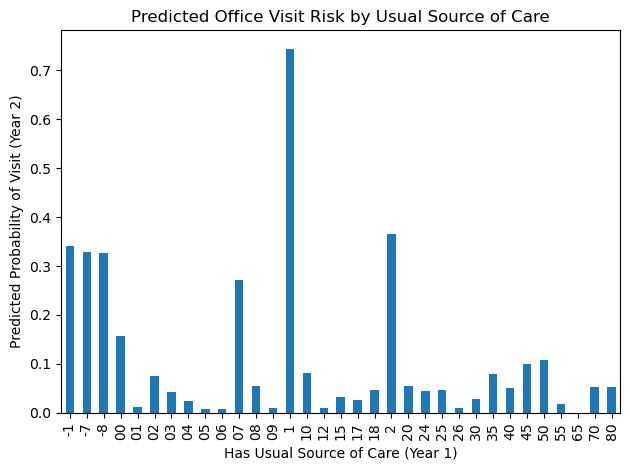

In [239]:
df_plot = X_test.copy()
df_plot["pred_prob"] = y_pred_prob
df_plot["any_visit_y2"] = y_test.values

df_plot.groupby("HAVEUS2")["pred_prob"].mean().plot(kind="bar")
plt.ylabel("Predicted Probability of Visit (Year 2)")
plt.xlabel("Has Usual Source of Care (Year 1)")
plt.title("Predicted Office Visit Risk by Usual Source of Care")
plt.tight_layout()
plt.show()


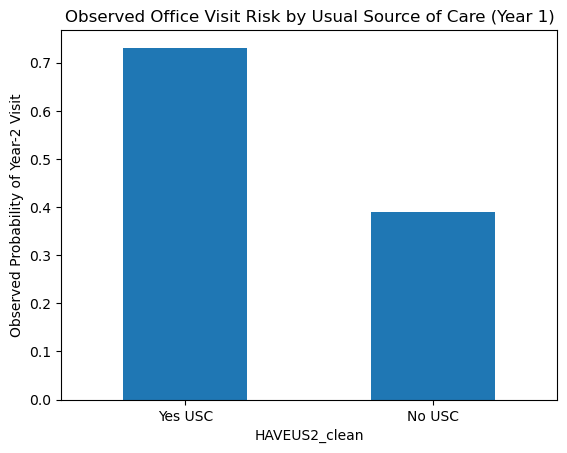

In [240]:
df_plot = df.copy()

df_plot["HAVEUS2_clean"] = df_plot["HAVEUS2"].replace(
    {-1: np.nan, -7: np.nan, -8: np.nan, -9: np.nan}
)

df_plot = df_plot[df_plot["HAVEUS2_clean"].isin([1, 2])]

df_plot.groupby("HAVEUS2_clean")["any_visit_y2"].mean().plot(
    kind="bar", rot=0
)
plt.xticks([0,1], ["Yes USC", "No USC"])
plt.ylabel("Observed Probability of Year-2 Visit")
plt.title("Observed Office Visit Risk by Usual Source of Care (Year 1)")
plt.show()


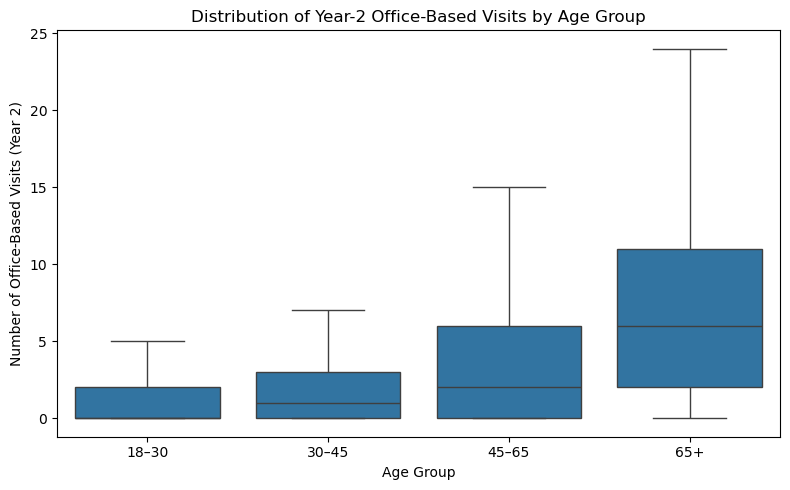

In [241]:
import seaborn as sns

df["age_group"] = pd.cut(
    df["AGE1X"],
    bins=[18, 30, 45, 65, 120],
    labels=["18–30", "30–45", "45–65", "65+"]
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="age_group", y="OBTOTVY2", showfliers=False)
plt.title("Distribution of Year-2 Office-Based Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Office-Based Visits (Year 2)")
plt.tight_layout()
plt.show()

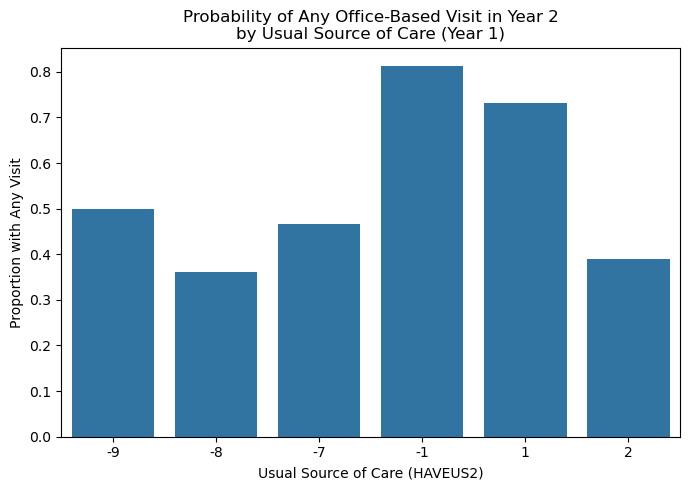

In [242]:
visit_rates = (
    df.groupby("HAVEUS2")["any_visit_y2"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(7, 5))
sns.barplot(data=visit_rates, x="HAVEUS2", y="any_visit_y2")
plt.title("Probability of Any Office-Based Visit in Year 2\nby Usual Source of Care (Year 1)")
plt.ylabel("Proportion with Any Visit")
plt.xlabel("Usual Source of Care (HAVEUS2)")
plt.tight_layout()
plt.show()


# Now for panel 18

In [244]:
# ---------- FILE PATHS ----------
# Longitudinal panel 18 (2014–2015) – h172
path_p18_long = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h172dat\h172.dat"

# Medical conditions files that contain panel 18:
# 2013 (Panel 18, Year 1) and 2014 (Panel 18, Year 2)
path_c2013 = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h162dat\h162.dat"
path_c2014 = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h170dat\h170.dat"

In [245]:
# Standard MEPS negative codes for missing / inapplicable
NEG_CODES = {-1, -7, -8, -9}

def to_numeric_clean(series):
    """
    Convert to numeric, then replace MEPS negative codes with NaN.
    """
    s = pd.to_numeric(series, errors="coerce")
    s = s.mask(s.isin(NEG_CODES), np.nan)
    return s

In [246]:
# Column positions from the h172 SAS layout
colspecs_long = [
    (0, 5),       # DUID      @1-5
    (5, 8),       # PID       @6-8
    (8, 16),      # DUPERSID  @9-16
    (16, 18),     # PANEL     @17-18
    (18, 19),     # YEARIND   @19
    (128, 130),   # REGION1   @129-130
    (360, 362),   # AGE1X     @361-362
    (384, 385),   # SEX       @385
    (387, 389),   # RACEV1X   @388-389
    (398, 399),   # HISPANX   @399
    (3145, 3147), # POVCATY1  @3146-3147
    (456, 458),   # EDRECODE  @457-458
    (4587, 4589), # INSCOVY1  @4588-4589
    (2342, 2344), # HAVEUS2   @2343-2344
    (2518, 2520), # PHNREG2   @2519-2520
    (2181, 2183), # CMNAFF3   @2182-2183
    (536, 538),   # RTHLTH1   @537-538
    (546, 548),   # MNHLTH1   @547-548
    (556, 558),   # HIBPDXY1  @557-558
    (898, 900),   # DIABDXY1  @899-900
    (5568, 5571)  # OBTOTVY2  @5569-5571
]

long_cols = [
    "DUID","PID","DUPERSID","PANEL","YEARIND","REGION1","AGE1X","SEX",
    "RACEV1X","HISPANX","POVCATY1","EDRECODE","INSCOVY1",
    "HAVEUS2","PHNREG2","CMNAFF3","RTHLTH1","MNHLTH1",
    "HIBPDXY1","DIABDXY1","OBTOTVY2"
]

df_p18_raw = pd.read_fwf(
    path_p18_long,
    colspecs=colspecs_long,
    names=long_cols,
    dtype=str
)

print("Raw p18 shape:", df_p18_raw.shape)
print(df_p18_raw.head())

Raw p18 shape: (16714, 21)
    DUID  PID  DUPERSID PANEL YEARIND REGION1 AGE1X SEX RACEV1X HISPANX  ...  \
0  40001  101  40001101    18       1      10    10   0      02       0  ...   
1  40001  102  40001102    18       1      00    10   0      01       0  ...   
2  40001  103  40001103    18       1      00    60   9      97       0  ...   
3  40001  104  40001104    18       1      00    60   9      97       0  ...   
4  40002  101  40002101    18       1      10    20   9      95       0  ...   

  EDRECODE INSCOVY1 HAVEUS2 PHNREG2 CMNAFF3 RTHLTH1 MNHLTH1 HIBPDXY1 DIABDXY1  \
0       01       20      1-      10      00      -1      02       02       02   
1       02       20      1-      10      00      -1      02       02       01   
2       04       20      1-      1-      00      -1      -1       -1       01   
3       04       20      1-      1-      00      -1      -1       -1       01   
4       01       20      30      10      00      -1      02       02       01   

  OBT

In [247]:
df_p18 = df_p18_raw.copy()

# numeric continuous-ish
df_p18["AGE1X"]    = to_numeric_clean(df_p18["AGE1X"]).astype("Int64")
df_p18["OBTOTVY2"] = to_numeric_clean(df_p18["OBTOTVY2"])

# categorical-but-coded numeric, clean negatives to NaN
for col in ["REGION1","SEX","RACEV1X","HISPANX",
            "POVCATY1","EDRECODE","INSCOVY1",
            "HAVEUS2","PHNREG2","CMNAFF3",
            "RTHLTH1","MNHLTH1","HIBPDXY1","DIABDXY1"]:
    df_p18[col] = to_numeric_clean(df_p18[col]).astype("Int64")

# binary outcome: any office-based visit in Year 2
df_p18["any_visit_y2"] = (df_p18["OBTOTVY2"] > 0).astype("Int8")

# Keep adults
df_p18_adult = df_p18[df_p18["AGE1X"] >= 18].copy()

print("Adults in p18 (before cancer filter):", df_p18_adult.shape)
print(df_p18_adult[["AGE1X","OBTOTVY2","any_visit_y2"]].describe())

Adults in p18 (before cancer filter): (10881, 22)
           AGE1X      OBTOTVY2  any_visit_y2
count    10881.0  10881.000000       10881.0
mean   49.820972     39.038324      0.082805
std     12.48688    149.931170        0.2756
min         20.0      0.000000           0.0
25%         50.0      0.000000           0.0
50%         50.0      0.000000           0.0
75%         60.0      0.000000           0.0
max         90.0    901.000000           1.0


In [248]:
# Positions for condition files (same layout for h162 and h170)
cond_colspecs = [
    (8, 16),   # DUPERSID @9-16
    (31, 33),  # PANEL    @32-33
    (69, 72)   # CCCODEX  @70-72
]
cond_cols = ["DUPERSID","PANEL","CCCODEX"]

cond13 = pd.read_fwf(path_c2013, colspecs=cond_colspecs,
                     names=cond_cols, dtype=str)
cond14 = pd.read_fwf(path_c2014, colspecs=cond_colspecs,
                     names=cond_cols, dtype=str)

# keep only panel 18 records from each year
cond13 = cond13[cond13["PANEL"] == "18"].copy()
cond14 = cond14[cond14["PANEL"] == "18"].copy()

cond_p18 = pd.concat([cond13, cond14], ignore_index=True)
print("Condition rows for panel 18:", cond_p18.shape)

Condition rows for panel 18: (119733, 3)


In [249]:
# CCCODEX 11–47 ≈ malignant neoplasms / cancers
cancer_codes = [f"{i:02d}" for i in range(11, 48)]

cond_p18["CCCODEX"] = cond_p18["CCCODEX"].str.strip()
cond_p18["has_cancer_cond"] = cond_p18["CCCODEX"].isin(cancer_codes)

# collapse to person-level flag
cancer_flag_p18 = (
    cond_p18.groupby("DUPERSID", as_index=False)["has_cancer_cond"]
            .max()
            .rename(columns={"has_cancer_cond": "has_cancer"})
)

print(cancer_flag_p18["has_cancer"].value_counts())

has_cancer
False    15449
Name: count, dtype: int64


In [250]:
df_p18_adult = df_p18_adult.merge(
    cancer_flag_p18,
    on="DUPERSID",
    how="left"
)

# If someone never appears in the conditions file: treat as no cancer
df_p18_adult["has_cancer"] = df_p18_adult["has_cancer"].fillna(False)

df_p18_adult_nonca = df_p18_adult[df_p18_adult["has_cancer"] == False].copy()

print("Panel 18 adults:", df_p18_adult.shape)
print("Panel 18 adult NON-cancer:", df_p18_adult_nonca.shape)

Panel 18 adults: (10881, 23)
Panel 18 adult NON-cancer: (10881, 23)


C:\Users\abhin\AppData\Local\Temp\ipykernel_41212\2066305536.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_p18_adult["has_cancer"] = df_p18_adult["has_cancer"].fillna(False)


In [251]:
df_all = pd.concat(
    [df_p16_adult_nonca, df_p17_adult_nonca, df_p18_adult_nonca],
    ignore_index=True
)

print("Pooled adults, non-cancer (panels 16–18):", df_all.shape)
print(df_all["PANEL"].value_counts())

Pooled adults, non-cancer (panels 16–18): (33551, 23)
PANEL
16    11489
17    11181
18    10881
Name: count, dtype: int64


In [252]:
df_all.isna().mean().sort_values(ascending=False)
df_all["any_visit_y2"].value_counts(normalize=True)

any_visit_y2
0    0.754404
1    0.245596
Name: proportion, dtype: Float64

# Panel 19

In [254]:
# ---------- FILE PATHS ----------
# Longitudinal panel 19 (2015–2016) – h183
path_p19_long = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h183dat\h183.dat"

# Medical conditions files that contain panel 19:
# 2014 (Panel 19, Year 1) and 2015 (Panel 19, Year 2)
path_c2014_p19 = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h170dat\h170.dat"
path_c2015_p19 = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h180dat\h180.dat"



In [255]:
usecols_long = [
    "DUID", "PID", "DUPERSID",
    "PANEL", "YEARIND",
    "AGE1X", "SEX", "RACEV1X", "HISPANX", "REGION1",
    "POVCATY1", "EDRECODE", "INSCOVY1",
    "HAVEUS2", "PHNREG2", "CMNAFF3",
    "RTHLTH1", "MNHLTH1",
    "HIBPDXY1", "DIABDXY1",
    "OBTOTVY2"
]

In [256]:
# ---------- PANEL 19 LONGITUDINAL (same layout as panel 18) ----------

# path for panel 19 longitudinal file (h183)
path_p19_long = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h183dat\h183.dat"

# reuse the SAME colspecs_long and long_cols you defined for panel 18
# (do NOT change them)
# colspecs_long = [...]
# long_cols = [...]

df_p19_raw = pd.read_fwf(
    path_p19_long,
    colspecs=colspecs_long,
    names=long_cols,
    dtype=str
)

print("Raw p19 shape:", df_p19_raw.shape)
print(df_p19_raw.head())

Raw p19 shape: (15898, 21)
    DUID  PID  DUPERSID PANEL YEARIND REGION1 AGE1X SEX RACEV1X HISPANX  ...  \
0  60001  101  60001101    19       1      10    50   9      95       0  ...   
1  60001  102  60001102    19       1      00    30   9      95       0  ...   
2  60001  103  60001103    19       1      00    50   9      95       0  ...   
3  60001  104  60001104    19       1      00    50   9      95       0  ...   
4  60001  105  60001105    19       1      00    60   9      97       0  ...   

  EDRECODE INSCOVY1 HAVEUS2 PHNREG2 CMNAFF3 RTHLTH1 MNHLTH1 HIBPDXY1 DIABDXY1  \
0       01       20      4-      1-      -1      01      47       46       01   
1       03       20      4-      1-      -1      02      -1       -1       01   
2       05       20      10      10      -1      02      -1       -1       02   
3       91       20      1-      10      -1      02      -1       -1       01   
4       91       20      1-      1-      -1      -1      -1       -1       02   

  OBT

In [257]:
df_p19 = df_p19_raw.copy()

# numeric conversions
df_p19["AGE1X"]    = pd.to_numeric(df_p19["AGE1X"], errors="coerce")
df_p19["OBTOTVY2"] = pd.to_numeric(df_p19["OBTOTVY2"], errors="coerce")

# keep adults
df_p19_adult = df_p19[df_p19["AGE1X"] >= 18].copy()
print("Panel 19 adults:", df_p19_adult.shape)


Panel 19 adults: (10357, 21)


In [258]:
df_p19_adult["any_visit_y2"] = (df_p19_adult["OBTOTVY2"] > 0).astype(int)
print(df_p19_adult["any_visit_y2"].value_counts(normalize=True))


any_visit_y2
0    0.99971
1    0.00029
Name: proportion, dtype: float64


In [259]:
cancer_cccodes = set([
    "011", "012", "013", "014", "015",
    "016", "017", "018", "019"
])

In [260]:
colspecs_cond = [
    (8, 16),   # DUPERSID  @9-16
    (69, 72)   # CCCODEX   @70-72
]

cond_cols = ["DUPERSID", "CCCODEX"]

In [261]:
path_c2014_p19 = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h170dat\h170.dat"
path_c2015_p19 = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h180dat\h180.dat"

cond_2014_p19 = pd.read_fwf(
    path_c2014_p19,
    colspecs=colspecs_cond,
    names=cond_cols,
    dtype=str
)

cond_2015_p19 = pd.read_fwf(
    path_c2015_p19,
    colspecs=colspecs_cond,
    names=cond_cols,
    dtype=str
)

df_cond_p19 = pd.concat([cond_2014_p19, cond_2015_p19], ignore_index=True)
df_cond_p19["has_cancer"] = df_cond_p19["CCCODEX"].isin(cancer_cccodes)

cancer_flag_p19 = (
    df_cond_p19.groupby("DUPERSID")["has_cancer"]
    .any()
    .reset_index()
)

In [262]:
df_p19_adult = df_p19_adult.merge(
    cancer_flag_p19,
    on="DUPERSID",
    how="left"
)

df_p19_adult["has_cancer"] = df_p19_adult["has_cancer"].fillna(False)

df_p19_adult_nonca = df_p19_adult[df_p19_adult["has_cancer"] == False].copy()

print("Panel 19 adult non-cancer shape:", df_p19_adult_nonca.shape)
print(df_p19_adult_nonca["has_cancer"].value_counts())
print(df_p19_adult_nonca["any_visit_y2"].value_counts(normalize=True))

Panel 19 adult non-cancer shape: (8725, 23)
has_cancer
False    8725
Name: count, dtype: int64
any_visit_y2
0    1.0
Name: proportion, dtype: float64


C:\Users\abhin\AppData\Local\Temp\ipykernel_41212\2880429317.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_p19_adult["has_cancer"] = df_p19_adult["has_cancer"].fillna(False)


In [263]:
df_pooled = pd.concat(
    [
        df_p16_adult_nonca,
        df_p17_adult_nonca,
        df_p18_adult_nonca,
        df_p19_adult_nonca
    ],
    ignore_index=True
)

print(df_pooled.shape)
print(df_pooled["PANEL"].value_counts().sort_index())

(42276, 23)
PANEL
16    11489
17    11181
18    10881
19     8725
Name: count, dtype: int64


# Panel 20 (last panel)

In [265]:
# ---------- PANEL 20 LONGITUDINAL ----------
path_p20_long = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Household Longitudinal Data Files\h193dat\h193.dat"

df_p20_raw = pd.read_fwf(
    path_p20_long,
    colspecs=colspecs_long,   # SAME colspecs pattern you used earlier
    names=long_cols,
    dtype=str
)

print("Raw p20 shape:", df_p20_raw.shape)


Raw p20 shape: (17017, 21)


In [266]:
df_p20_raw["AGE1X"] = pd.to_numeric(df_p20_raw["AGE1X"], errors="coerce")

df_p20_adult = df_p20_raw[df_p20_raw["AGE1X"] >= 18].copy()
print("Adults only:", df_p20_adult.shape)


Adults only: (10829, 21)


In [267]:
# ---------- CONDITION FILE COLSPECS ----------
cond_colspecs = [
    (8, 16),    # DUPERSID @9-16
    (69, 72)    # CCCODEX  @70-72
]

cond_cols = ["DUPERSID", "CCCODEX"]


In [268]:
path_c2015 = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h180dat\h180.dat"

df_c2015 = pd.read_fwf(
    path_c2015,
    colspecs=cond_colspecs,
    names=cond_cols,
    dtype=str
)


In [269]:
path_c2016 = r"C:\Users\abhin\OneDrive\Desktop\NEU\NU\ALY6980\MEPS Data Group 3\Medical Conditions Files\h190dat\h190.dat"

df_c2016 = pd.read_fwf(
    path_c2016,
    colspecs=cond_colspecs,
    names=cond_cols,
    dtype=str
)


In [270]:
cancer_cccodes = set(str(i) for i in range(11, 46))


In [271]:
df_cond_p20 = pd.concat([df_c2015, df_c2016], ignore_index=True)

df_cond_p20["has_cancer"] = df_cond_p20["CCCODEX"].isin(cancer_cccodes)

cancer_flags = (
    df_cond_p20.groupby("DUPERSID")["has_cancer"]
    .any()
    .reset_index()
)


In [272]:
df_p20_adult = df_p20_adult.merge(
    cancer_flags,
    on="DUPERSID",
    how="left"
)

df_p20_adult["has_cancer"] = df_p20_adult["has_cancer"].fillna(False)

df_p20_adult_nonca = df_p20_adult[df_p20_adult["has_cancer"] == False].copy()

print("Panel 20 adult non-cancer:", df_p20_adult_nonca.shape)


Panel 20 adult non-cancer: (10829, 22)


C:\Users\abhin\AppData\Local\Temp\ipykernel_41212\724791649.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_p20_adult["has_cancer"] = df_p20_adult["has_cancer"].fillna(False)


In [273]:
df_p20_adult_nonca["OBTOTVY2"] = pd.to_numeric(
    df_p20_adult_nonca["OBTOTVY2"], errors="coerce"
)

df_p20_adult_nonca["any_visit_y2"] = (
    df_p20_adult_nonca["OBTOTVY2"] > 0
).astype(int)

df_p20_adult_nonca["PANEL"] = "20"


In [274]:
df_all_panels = pd.concat(
    [
        df_p16_adult_nonca,
        df_p17_adult_nonca,
        df_p18_adult_nonca,
        df_p19_adult_nonca,
        df_p20_adult_nonca
    ],
    ignore_index=True
)

print("FINAL pooled dataset:", df_all_panels.shape)
print(df_all_panels["PANEL"].value_counts())


FINAL pooled dataset: (53105, 23)
PANEL
16    11489
17    11181
18    10881
20    10829
19     8725
Name: count, dtype: int64


In [354]:
print(df_all_panels.columns)

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'REGION1', 'AGE1X',
       'SEX', 'RACEV1X', 'HISPANX', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'HAVEUS2', 'PHNREG2', 'CMNAFF3', 'RTHLTH1', 'MNHLTH1', 'HIBPDXY1',
       'DIABDXY1', 'OBTOTVY2', 'any_visit_y2', 'has_cancer'],
      dtype='object')


# eda

In [356]:
y = df_all_panels["OBTOTVY2"]

print("Mean:", y.mean())
print("Variance:", y.var())
print("Percent zero:", (y == 0).mean())
print("Max:", y.max())
print("Top counts:")
print(y.value_counts().head(10))

Mean: 17.62031400192246
Variance: 8449.92133266356
Percent zero: 0.7835420393559929
Max: 999.0
Top counts:
OBTOTVY2
0.0    41610
1.0     1854
2.0     1208
3.0      850
4.0      628
5.0      472
6.0      434
7.0      330
8.0      269
9.0      236
Name: count, dtype: int64


In [360]:
# Remove MEPS missing codes
df_all_panels = df_all_panels.replace([999, -1, -7, -8, -9], np.nan)

In [362]:
model_vars = [
    "OBTOTVY2","AGE1X","SEX","RACEV1X","POVCATY1",
    "INSCOVY1","RTHLTH1","MNHLTH1",
    "HIBPDXY1","DIABDXY1","PANEL"
]

df_model = df_all_panels[model_vars].dropna().copy()

In [364]:
categorical_vars = ["SEX","RACEV1X","POVCATY1","INSCOVY1","PANEL"]

for col in categorical_vars:
    df_model[col] = df_model[col].astype("category")

In [366]:
y = df_model["OBTOTVY2"]

print("Mean:", y.mean())
print("Variance:", y.var())
print("Percent zero:", (y == 0).mean())
print("Max:", y.max())

Mean: 12.469122426868905
Variance: 4913.658619769421
Percent zero: 0.7507654623392529
Max: 997.0


In [370]:
df_all_panels = df_all_panels.replace([997, 998, 999], np.nan)

In [372]:
model_vars = [
    "OBTOTVY2","AGE1X","SEX","RACEV1X","POVCATY1",
    "INSCOVY1","RTHLTH1","MNHLTH1",
    "HIBPDXY1","DIABDXY1","PANEL"
]

df_model = df_all_panels[model_vars].copy()

In [374]:
df_model = df_model.dropna()

In [376]:
# numeric
numeric_vars = ["OBTOTVY2","AGE1X","RTHLTH1","MNHLTH1","HIBPDXY1","DIABDXY1"]
for col in numeric_vars:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# categorical
categorical_vars = ["SEX","RACEV1X","POVCATY1","INSCOVY1","PANEL"]
for col in categorical_vars:
    df_model[col] = df_model[col].astype("category")

# drop any leftover NA again
df_model = df_model.dropna()

In [378]:
for col in categorical_vars:
    df_model[col] = df_model[col].cat.remove_unused_categories()

In [382]:
import numpy as np
import pandas as pd

model_vars = [
    "OBTOTVY2","AGE1X","SEX","RACEV1X","POVCATY1",
    "INSCOVY1","RTHLTH1","MNHLTH1",
    "HIBPDXY1","DIABDXY1","PANEL"
]

df_model = df_all_panels[model_vars].copy()

# Remove MEPS special codes
df_model = df_model.replace([997, 998, 999, -1, -7, -8, -9], np.nan)

# Drop missing
df_model = df_model.dropna()

In [384]:
y = df_model["OBTOTVY2"]

In [386]:
categorical_vars = ["SEX","RACEV1X","POVCATY1","INSCOVY1","PANEL"]

X = df_model.drop(columns=["OBTOTVY2"])

X = pd.get_dummies(X, columns=categorical_vars, drop_first=True)

In [388]:
import statsmodels.api as sm

X = sm.add_constant(X)

In [392]:
print(X.dtypes)

const          float64
AGE1X          Float64
RTHLTH1         object
MNHLTH1         object
HIBPDXY1        object
                ...   
INSCOVY1_9-       bool
PANEL_17          bool
PANEL_18          bool
PANEL_19          bool
PANEL_20          bool
Length: 69, dtype: object


In [394]:
X = X.apply(pd.to_numeric, errors="coerce")

In [396]:
# Drop any rows that became NaN during coercion
mask = X.notnull().all(axis=1)
X = X[mask]
y = y[mask]

In [398]:
X = sm.add_constant(X)

In [400]:
model_nb = sm.NegativeBinomial(y, X).fit()
print(model_nb.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [276]:
# Outcome distribution
df_all_panels["any_visit_y2"].value_counts(normalize=True)

# Panel-wise outcome rate
df_all_panels.groupby("PANEL")["any_visit_y2"].mean()

# Missingness overview (top only)
df_all_panels.isna().mean().sort_values(ascending=False).head(10)


has_cancer    0.426890
RTHLTH1       0.199190
HAVEUS2       0.180491
PHNREG2       0.128029
MNHLTH1       0.086169
HIBPDXY1      0.083043
REGION1       0.002053
OBTOTVY2      0.000904
HISPANX       0.000716
POVCATY1      0.000640
dtype: float64

In [277]:
df_all_panels["has_cancer"] = df_all_panels["has_cancer"].fillna(0)


In [278]:
df_eda = df_all_panels.copy()

# Explicitly mark non-cancer
df_eda["has_cancer"] = df_eda["has_cancer"].fillna(0)


In [279]:
missing_summary = (
    df_eda.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_summary.columns = ["Variable", "Proportion Missing"]
missing_summary


,Variable,Proportion Missing
0,RTHLTH1,0.199190
1,HAVEUS2,0.180491
2,PHNREG2,0.128029
3,MNHLTH1,0.086169
4,HIBPDXY1,0.083043
5,REGION1,0.002053
6,OBTOTVY2,0.000904
7,HISPANX,0.000716
8,POVCATY1,0.000640
9,EDRECODE,0.000395


In [280]:
df_eda["RTHLTH1_missing"] = df_eda["RTHLTH1"].isna()

df_eda.groupby("RTHLTH1_missing")["any_visit_y2"].mean()


RTHLTH1_missing
False    0.248971
True     0.081206
Name: any_visit_y2, dtype: Float64

In [281]:
df_eda["HAVEUS2_missing"] = df_eda["HAVEUS2"].isna()
df_eda.groupby("HAVEUS2_missing")["any_visit_y2"].mean()

HAVEUS2_missing
False    0.246461
True     0.075222
Name: any_visit_y2, dtype: Float64

In [282]:
cluster_cols = [
    # Demographics
    "AGE1X", "SEX", "RACEV1X", "HISPANX",
    "POVCATY1", "EDRECODE", "REGION1",

    # Insurance / access
    "INSCOVY1", "HAVEUS2", "PHNREG2", "CMNAFF3",

    # Health status
    "RTHLTH1", "MNHLTH1",
    "HIBPDXY1", "DIABDXY1"
]

df_cluster = df_eda[cluster_cols].copy()
print(df_cluster.shape)


(53105, 15)


In [283]:
# Create health profile features
df_cluster["chronic_count"] = (
    (df_cluster["HIBPDXY1"] == "1").astype(int) +
    (df_cluster["DIABDXY1"] == "1").astype(int)
)


In [284]:
# Access barrier flag
df_cluster["any_access_barrier"] = (
    (df_cluster["HAVEUS2"] != "1") |
    (df_cluster["PHNREG2"] != "1") |
    (df_cluster["CMNAFF3"] == "1")
).astype(int)

In [285]:
# Drop rows with missing values
print("Before dropna:", df_cluster.shape)
df_cluster = df_cluster.dropna()
print("After dropna:", df_cluster.shape)

Before dropna: (53105, 17)
After dropna: (42277, 17)


In [286]:
# Encode + scale (required for clustering)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [287]:
# Split numeric vs categorical:
num_cols = ["AGE1X", "chronic_count", "any_access_barrier"]
cat_cols = [c for c in df_cluster.columns if c not in num_cols]

In [288]:
# ---------- NUMERIC FEATURES ----------
num_cols = [
    "AGE1X",        # age
    "HIBPDXY1",     # hypertension
    "DIABDXY1",     # diabetes
]

# ---------- CATEGORICAL FEATURES ----------
cat_cols = [
    "SEX",
    "RACEV1X",
    "HISPANX",
    "REGION1",
    "POVCATY1",
    "EDRECODE",
    "INSCOVY1",
    "HAVEUS2",
    "PHNREG2",
    "CMNAFF3",
    "RTHLTH1",
    "MNHLTH1",
]

# ---------- FINAL FEATURE LIST ----------
feature_cols = num_cols + cat_cols


In [289]:
# 1. Start from your pooled dataset
df_cluster = df_eda[feature_cols].copy()

# 2. Force numeric columns to numbers (bad codes -> NaN)
for col in num_cols:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors="coerce")

print(df_cluster[num_cols].head())  # sanity check

# 3. Drop rows where core numeric features are missing
df_cluster = df_cluster.dropna(subset=num_cols).copy()
print("After dropping NaNs in numeric cols:", df_cluster.shape)

# 4. Treat categoricals as strings
for col in cat_cols:
    df_cluster[col] = df_cluster[col].astype(str)

# 5. Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

# 6. Build clustering matrix
X_cluster = preprocessor.fit_transform(df_cluster)

print("Clustering matrix shape:", X_cluster.shape)

   AGE1X  HIBPDXY1  DIABDXY1
0   54.0       1.0       1.0
1   60.0       2.0       2.0
2   85.0       2.0       2.0
3   60.0       2.0       2.0
4   39.0       2.0       2.0
After dropping NaNs in numeric cols: (38723, 15)
Clustering matrix shape: (38723, 447)


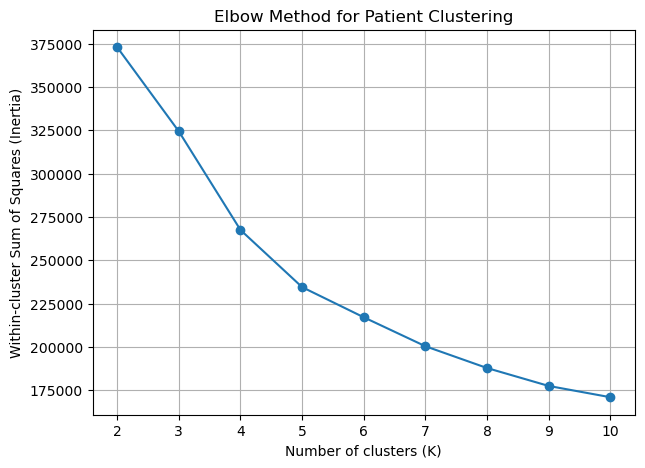

In [290]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_cluster)
    inertia.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Patient Clustering")
plt.grid(True)
plt.show()


In [291]:
k_final = 4

kmeans = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster)

df_cluster["cluster"] = cluster_labels

df_cluster["cluster"].value_counts(normalize=True)


cluster
1    0.372414
0    0.296697
2    0.296310
3    0.034579
Name: proportion, dtype: float64

In [292]:
cluster_props = df_cluster["cluster"].value_counts(normalize=True).sort_index()

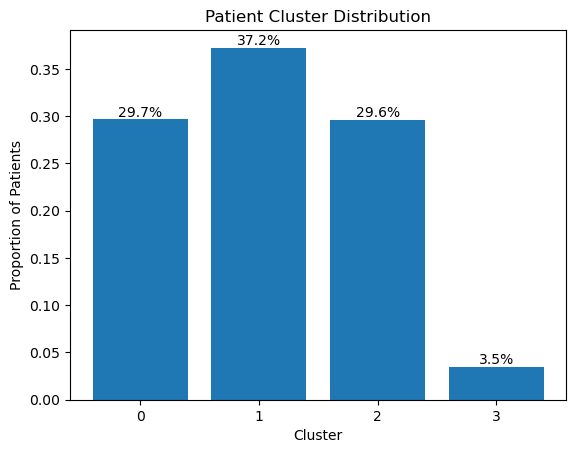

In [293]:
plt.figure()
bars = plt.bar(cluster_props.index.astype(str), cluster_props.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Cluster")
plt.ylabel("Proportion of Patients")
plt.title("Patient Cluster Distribution")
plt.show()


## cluster summary table

In [295]:
profile_vars = [
    "AGE1X",
    "HIBPDXY1",
    "DIABDXY1",
    "HAVEUS2",
    "RTHLTH1",
    "MNHLTH1"
]

for col in profile_vars:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors="coerce")


In [296]:
df_cluster.columns


Index(['AGE1X', 'HIBPDXY1', 'DIABDXY1', 'SEX', 'RACEV1X', 'HISPANX', 'REGION1',
       'POVCATY1', 'EDRECODE', 'INSCOVY1', 'HAVEUS2', 'PHNREG2', 'CMNAFF3',
       'RTHLTH1', 'MNHLTH1', 'cluster'],
      dtype='object')

In [297]:
df_cluster["cluster"].value_counts(normalize=True).round(3)


cluster
1    0.372
0    0.297
2    0.296
3    0.035
Name: proportion, dtype: float64

In [298]:
df_cluster[profile_vars].dtypes

AGE1X       Float64
HIBPDXY1    float64
DIABDXY1    float64
HAVEUS2     float64
RTHLTH1     float64
MNHLTH1     float64
dtype: object

In [299]:
df_cluster["any_visit_y2"] = df_eda.loc[df_cluster.index, "any_visit_y2"]


In [300]:
profile_vars = ["AGE1X", "HIBPDXY1", "DIABDXY1"]

cluster_profile = (
    df_cluster
    .groupby("cluster")[profile_vars]
    .mean()
    .round(2)
)

In [301]:
profile_vars = [
    "AGE1X",
    "HIBPDXY1",
    "DIABDXY1",
    "any_visit_y2"
]

cluster_profile = (
    df_cluster
    .groupby("cluster")[profile_vars]
    .mean()
    .round(2)
)

cluster_profile

,AGE1X,HIBPDXY1,DIABDXY1,any_visit_y2
cluster,,,,
0,43.67,1.69,1.89,0.62
1,52.01,0.29,1.59,0.22
2,43.46,0.65,1.49,0.05
3,56.26,22.70,16.95,0.02


In [302]:
cluster_sizes = (
    df_cluster["cluster"]
    .value_counts(normalize=True)
    .rename("proportion")
    .round(3)
)

cluster_sizes


cluster
1    0.372
0    0.297
2    0.296
3    0.035
Name: proportion, dtype: float64

In [303]:
df_cluster.groupby("cluster")["any_visit_y2"].mean()

cluster
0    0.619897
1    0.222176
2    0.051856
3    0.023898
Name: any_visit_y2, dtype: Float64

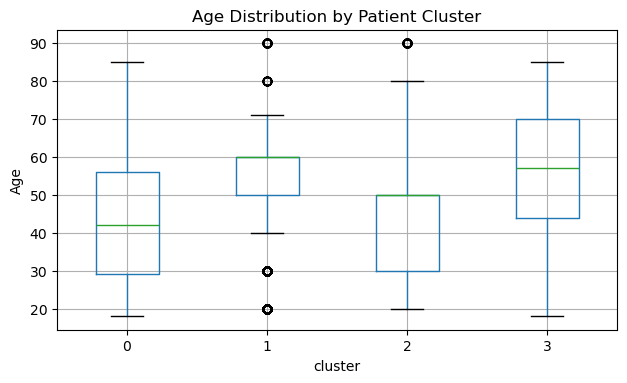

In [304]:
df_cluster.boxplot(
    column="AGE1X",
    by="cluster",
    figsize=(7,4)
)
plt.title("Age Distribution by Patient Cluster")
plt.suptitle("")
plt.ylabel("Age")
plt.show()


In [305]:
X_base = df_eda[[
    "AGE1X", "HIBPDXY1", "DIABDXY1", "HAVEUS2", "RTHLTH1"
]]
y = df_eda["any_visit_y2"]

# clean numeric coercion
X_base = X_base.apply(pd.to_numeric, errors="coerce")
mask = X_base.notna().all(axis=1)

X_base = X_base[mask]
y = y.loc[X_base.index]


In [306]:
X_clustered = X_base.copy()
X_clustered["cluster"] = df_cluster.loc[X_base.index, "cluster"]

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X_clustered)


In [307]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_base, y)

auc_base = roc_auc_score(y, model_base.predict_proba(X_base)[:,1])
auc_base


0.7666331614191705

In [308]:
model_cluster = LogisticRegression(max_iter=1000)
model_cluster.fit(X_clustered, y)

auc_cluster = roc_auc_score(y, model_cluster.predict_proba(X_clustered)[:,1])
auc_cluster

0.7708670057881513

In [309]:
model_poly = LogisticRegression(max_iter=2000)
model_poly.fit(X_poly, y)

auc_poly = roc_auc_score(y, model_poly.predict_proba(X_poly)[:,1])
auc_poly

C:\Users\abhin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8021440443446454

In [310]:
pd.DataFrame({
    "Model": ["Baseline", "Baseline + Cluster", "Polynomial + Cluster"],
    "ROC_AUC": [auc_base, auc_cluster, auc_poly]
})

,Model,ROC_AUC
0,Baseline,0.766633
1,Baseline + Cluster,0.770867
2,Polynomial + Cluster,0.802144


### auc_train

In [312]:
# Replace weird dash-only values with NaN
df_model = df_model.replace(["-", "1-", "-1", "-7", "-8", "-9"], pd.NA)

In [313]:
for col in num_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")


In [314]:
df_model = df_model.dropna().copy()


In [315]:
for col in df_model.columns:
    if df_model[col].dtype == "object":
        print(col, df_model[col].unique()[:10])


In [316]:
# Strip whitespace everywhere
df_eda = df_eda.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Replace known bad placeholders
df_eda = df_eda.replace({
    "-": None,
    "": None
})


C:\Users\abhin\AppData\Local\Temp\ipykernel_41212\2581429102.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_eda = df_eda.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [317]:
for col in num_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")


In [318]:
for col in num_cols:
    try:
        pd.to_numeric(df_eda[col])
    except:
        print("Problem column:", col)
        print(df_eda[col].unique()[:20])


In [319]:
import re

# IMPORTANT: run this on df_cluster (or whatever df you're converting)
for col in num_cols:
    # force to string first so we can clean consistently
    s = df_cluster[col].astype(str).str.strip()

    # replace any standalone dash (with or without spaces) with NaN
    s = s.replace(r"^\s*-\s*$", np.nan, regex=True)

    # also treat blanks as NaN
    s = s.replace(r"^\s*$", np.nan, regex=True)

    # write back + convert safely
    df_cluster[col] = pd.to_numeric(s, errors="coerce")

In [320]:
for col in num_cols:
    bad = df_cluster[col].astype(str).str.contains(r"^\s*-\s*$", regex=True, na=False)
    if bad.any():
        print("Dash found in:", col)
        print(df_cluster.loc[bad, col].head(10).tolist())
        break


In [321]:
df_cluster[num_cols] = df_cluster[num_cols].apply(pd.to_numeric, errors="coerce")


In [322]:
(df_cluster[num_cols].astype(str) == "-").any()


AGE1X       False
HIBPDXY1    False
DIABDXY1    False
dtype: bool

In [323]:
dash_chars = ["-", "–", "—", "−"]  # hyphen, en dash, em dash, minus

for col in df_cluster.columns:
    s = df_cluster[col].astype(str).str.strip()
    if s.isin(dash_chars).any():
        print("Found dash in column:", col)
        print("Examples:", s[s.isin(dash_chars)].head(10).tolist())
        break


Found dash in column: SEX
Examples: ['-', '-', '-']


In [324]:
for col in num_cols:
    s = df_cluster[col].astype(str).str.strip()
    bad = pd.to_numeric(s, errors="coerce").isna() & s.notna() & (s != "")
    if bad.any():
        print("Non-numeric values in:", col)
        print(s[bad].value_counts().head(15))

In [325]:
# treat "-" as missing for categoricals (and trim whitespace)
for col in cat_cols:
    df_cluster[col] = df_cluster[col].astype(str).str.strip()
    df_cluster.loc[df_cluster[col].isin(["-", "–", "—", "−"]), col] = np.nan


In [326]:
df_cluster = df_cluster.dropna(subset=cat_cols + num_cols).copy()


In [327]:
X_cluster = preprocessor.fit_transform(df_cluster)


In [328]:
# 1) Make sure you clean the SAME X you are passing into predict_proba
X_train = X_train.copy()
X_test  = X_test.copy()

for col in cat_cols:
    X_train[col] = X_train[col].astype(str).str.strip()
    X_test[col]  = X_test[col].astype(str).str.strip()

    X_train.loc[X_train[col].isin(["-", "–", "—", "−"]), col] = np.nan
    X_test.loc[X_test[col].isin(["-", "–", "—", "−"]), col] = np.nan

# choose ONE approach:
# Option A: drop missing rows (prof-friendly)
X_train = X_train.dropna(subset=cat_cols + num_cols)
y_train = y_train.loc[X_train.index]
X_test  = X_test.dropna(subset=cat_cols + num_cols)
y_test  = y_test.loc[X_test.index]

# OR Option B: keep missing as explicit category
# for col in cat_cols:
#     X_train[col] = X_train[col].fillna("Missing")
#     X_test[col]  = X_test[col].fillna("Missing")


In [329]:
def clean_meps_strings(df):
    df = df.copy()
    # apply to all object columns (categoricals)
    obj_cols = df.select_dtypes(include="object").columns

    for c in obj_cols:
        s = df[c].astype(str).str.strip()
        # common junk tokens seen in your data
        s = s.replace({"-": np.nan, "1-": np.nan, "8-": np.nan, "9-": np.nan})
        df[c] = s
    return df

X_train_clean = clean_meps_strings(X_train)
X_test_clean  = clean_meps_strings(X_test)


In [330]:
X_train_clean = X_train_clean.dropna(subset=num_cols + cat_cols)
y_train2 = y_train.loc[X_train_clean.index]

X_test_clean = X_test_clean.dropna(subset=num_cols + cat_cols)
y_test2 = y_test.loc[X_test_clean.index]


In [331]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1) Clean '-' and '1-' etc BEFORE modeling
def clean_meps_strings(df):
    df = df.copy()
    obj_cols = df.select_dtypes(include="object").columns
    for c in obj_cols:
        s = df[c].astype(str).str.strip()
        s = s.replace({"-": None, "1-": None, "8-": None, "9-": None})
        df[c] = s
    return df

X_train_c = clean_meps_strings(X_train)
X_test_c  = clean_meps_strings(X_test)

# 2) If professor said avoid imputing: drop rows with missing in model cols
model_cols = num_cols + cat_cols
X_train_c = X_train_c.dropna(subset=model_cols)
y_train_c = y_train.loc[X_train_c.index]

X_test_c  = X_test_c.dropna(subset=model_cols)
y_test_c  = y_test.loc[X_test_c.index]

# 3) Build pipeline: poly ONLY on numeric cols
numeric_pipe = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

categorical_pipe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

model_poly = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])

# 4) Fit + AUC
model_poly.fit(X_train_c, y_train_c)

train_auc = roc_auc_score(y_train_c, model_poly.predict_proba(X_train_c)[:, 1])
test_auc  = roc_auc_score(y_test_c,  model_poly.predict_proba(X_test_c)[:, 1])

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)


Train AUC: 0.8412108145686241
Test AUC: 0.829645235181172


In [332]:
results = pd.DataFrame({
    "Model": ["Baseline", "Baseline + Cluster", "Polynomial + Cluster", "Polynomial (fixed)"],
    "ROC_AUC": [0.766633, 0.770867, 0.802144, 0.829645]
})
results

,Model,ROC_AUC
0,Baseline,0.766633
1,Baseline + Cluster,0.770867
2,Polynomial + Cluster,0.802144
3,Polynomial (fixed),0.829645


In [338]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model_poly.predict_proba(X_test_c)[:,1] >= 0.5).astype(int)

print(confusion_matrix(y_test_c, y_pred))
print(classification_report(y_test_c, y_pred))

[[1095  565]
 [ 351 1795]]
              precision    recall  f1-score   support

           0       0.76      0.66      0.71      1660
           1       0.76      0.84      0.80      2146

    accuracy                           0.76      3806
   macro avg       0.76      0.75      0.75      3806
weighted avg       0.76      0.76      0.76      3806



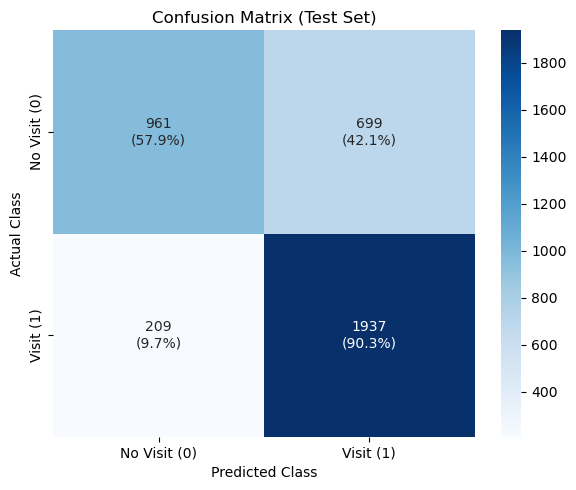

In [340]:


# Predict using chosen threshold (use 0.41 if optimized)
threshold = 0.41
y_prob = model_poly.predict_proba(X_test_c)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred)

# Compute percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels
labels = np.array([
    [f"{cm[0,0]}\n({cm_percent[0,0]:.1%})", 
     f"{cm[0,1]}\n({cm_percent[0,1]:.1%})"],
    [f"{cm[1,0]}\n({cm_percent[1,0]:.1%})", 
     f"{cm[1,1]}\n({cm_percent[1,1]:.1%})"]
])

plt.figure(figsize=(6,5))
sns.heatmap(cm, 
            annot=labels, 
            fmt="", 
            cmap="Blues",
            xticklabels=["No Visit (0)", "Visit (1)"],
            yticklabels=["No Visit (0)", "Visit (1)"])

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

In [342]:
import numpy as np
from sklearn.metrics import f1_score

probs = model_poly.predict_proba(X_test_c)[:,1]
thresholds = np.linspace(0.1, 0.9, 81)

best_t, best_f1 = None, -1
for t in thresholds:
    pred = (probs >= t).astype(int)
    f1 = f1_score(y_test_c, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("Best threshold:", best_t, "Best F1:", best_f1)


Best threshold: 0.41000000000000003 Best F1: 0.8101212881639481


In [344]:
import numpy as np
import pandas as pd

# Get feature names after preprocessing
feature_names = model_poly.named_steps["preprocess"].get_feature_names_out()
coefs = model_poly.named_steps["clf"].coef_.ravel()

top = pd.DataFrame({"feature": feature_names, "coef": coefs})
top["abs_coef"] = top["coef"].abs()
top = top.sort_values("abs_coef", ascending=False).head(20)
top[["feature","coef"]]

,feature,coef
1,num__HIBPDXY1,-2.670924
2,num__DIABDXY1,-2.572649
6,num__HIBPDXY1^2,1.909816
4,num__AGE1X HIBPDXY1,-1.099018
8,num__DIABDXY1^2,1.012630
7,num__HIBPDXY1 DIABDXY1,1.005965
44,cat__POVCATY1_20,0.950247
34,cat__REGION1_02,0.936152
76,cat__HAVEUS2_-7,-0.898950
145,cat__CMNAFF3_23,0.889480


In [348]:
print(df_cluster.dtypes)

AGE1X           float64
HIBPDXY1        float64
DIABDXY1        float64
SEX              object
RACEV1X          object
HISPANX          object
REGION1          object
POVCATY1         object
EDRECODE         object
INSCOVY1         object
HAVEUS2          object
PHNREG2          object
CMNAFF3          object
RTHLTH1          object
MNHLTH1          object
cluster           int32
any_visit_y2      Int32
dtype: object


In [350]:
df.columns

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'AGE1X', 'SEX',
       'RACEV1X', 'HISPANX', 'REGION1', 'POVCATY1', 'EDRECODE', 'INSCOVY1',
       'HAVEUS2', 'PHNREG2', 'CMNAFF3', 'RTHLTH1', 'RTHLTH2', 'MNHLTH1',
       'MNHLTH2', 'HIBPDXY1', 'HIBPDXY2', 'DIABDXY1', 'DIABDXY2', 'OBTOTVY2',
       'any_visit_y2', 'age_group'],
      dtype='object')